# TASK 3 — Explainability: SHAP + LIME (one correct sample, one wrong sample)

In [21]:
# TASK 3 — EXPLAINABILITY (SHAP + LIME) FOR ONE CORRECT AND ONE WRONG SAMPLE

!pip -q install shap lime scikit-image --break-system-packages 2>/dev/null || pip -q install shap lime scikit-image

import json
import os
import urllib.request
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from torchvision import transforms

# Set Random Seed for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# File Directory Paths
ARTIFACT_DIR = Path("/kaggle/working/task3_artifacts_fixed")
MODELS_DIR = Path("/kaggle/working/models")
XAI_DIR = Path("/kaggle/working/task3_xai_artifacts")

for path in [ARTIFACT_DIR, MODELS_DIR, XAI_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Dataset & Class Configuration
CLASSES = ["AMD", "DME", "ERM", "NO", "RAO", "RVO", "VID"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

# Image Patch & Grid Setup
IMAGE_SIZE = 128
GRID_SIZE = 8  # 8x8 grid of patches
PATCH_SIZE = IMAGE_SIZE // GRID_SIZE  # 16x16 patch size

# Training Hyperparameters
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 20
PATIENCE = 5
LABEL_SMOOTHING = 0.05
WEIGHTS = None  


Device: cpu


In [22]:
# =========================
# 4. MODEL ARCHITECTURE 
# =========================
def grid_adjacency(n=GRID_SIZE, weighted=False):
    A = np.zeros((n * n, n * n), dtype=np.float32)
    for r in range(n):
        for c in range(n):
            i = r * n + c
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    if dr == 0 and dc == 0:
                        continue
                    rr, cc = r + dr, c + dc
                    if 0 <= rr < n and 0 <= cc < n:
                        j = rr * n + cc
                        d = (dr * dr + dc * dc) ** 0.5
                        A[i, j] = 1.0 / d if weighted else 1.0
    A += np.eye(n * n, dtype=np.float32)
    deg = A.sum(1)
    Dinv = np.diag(1.0 / np.sqrt(np.maximum(deg, 1e-8)))
    return Dinv @ A @ Dinv


def knn_adjacency(X, k=8, weighted=False):
    B, N, Fdim = X.shape
    A = torch.zeros(B, N, N, device=X.device)
    dist = torch.cdist(X, X)
    vals, inds = torch.topk(dist, k=min(k + 1, N), largest=False)
    for b in range(B):
        for i in range(N):
            js = inds[b, i, 1:]
            if weighted:
                sigma = vals[b, i, 1:].mean().clamp_min(1e-6)
                A[b, i, js] = torch.exp(-(vals[b, i, 1:] ** 2) / (sigma ** 2))
            else:
                A[b, i, js] = 1.0
    A = torch.maximum(A, A.transpose(1, 2))
    A = A + torch.eye(N, device=X.device).unsqueeze(0)
    deg = A.sum(-1)
    return A / torch.sqrt(deg.unsqueeze(-1) * deg.unsqueeze(-2) + 1e-8)


class PatchEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, out_dim), nn.ReLU(inplace=True),
            nn.Dropout(0.10)
        )

    def forward(self, x):
        B = x.size(0)
        p = x.unfold(2, PATCH_SIZE, PATCH_SIZE).unfold(3, PATCH_SIZE, PATCH_SIZE)
        p = p.contiguous().view(B, 1, GRID_SIZE * GRID_SIZE, PATCH_SIZE, PATCH_SIZE)
        p = p.permute(0, 2, 1, 3, 4).reshape(B * GRID_SIZE * GRID_SIZE, 1, PATCH_SIZE, PATCH_SIZE)
        z = self.net(p)
        return z.view(B, GRID_SIZE * GRID_SIZE, -1)


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0, batch_norm=False):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)
        self.bn = nn.BatchNorm1d(out_dim) if batch_norm else None
        self.drop = nn.Dropout(dropout)
        self.res = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x, A):
        h = torch.bmm(A, x)
        h = self.lin(h)
        if self.bn is not None:
            h = self.bn(h.reshape(-1, h.size(-1))).view(h.size(0), h.size(1), -1)
        return self.drop(F.relu(h)) + self.res(x)


class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Linear(in_dim * 2, out_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, A):
        neigh = torch.bmm(A, x)
        return self.drop(F.relu(self.lin(torch.cat([x, neigh], dim=-1))))


class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
        self.a_src = nn.Parameter(torch.randn(out_dim) * 0.02)
        self.a_dst = nn.Parameter(torch.randn(out_dim) * 0.02)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, A):
        h = self.lin(x)
        e = F.leaky_relu(
            (h * self.a_src).sum(-1).unsqueeze(-1) + (h * self.a_dst).sum(-1).unsqueeze(-2), 0.2
        )
        e = e.masked_fill(~(A > 0), -9e15)
        att = F.softmax(e, dim=-1)
        return self.drop(F.relu(torch.bmm(att, h)))


class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(dim, dim // 2), nn.Tanh(), nn.Linear(dim // 2, 1))

    def forward(self, z):
        a = torch.softmax(self.score(z).squeeze(-1), dim=1).unsqueeze(-1)
        return (z * a).sum(1)


class GlobalImageBranch(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 5, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, out_dim), nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class GNNClassifier(nn.Module):
    def __init__(self, variant="GCN", hidden=128, layers=3, dropout=0.30,
                 batch_norm=True, graph="spatial", weighted_edges=True,
                 global_branch=True):
        super().__init__()
        self.variant = variant
        self.graph = graph
        self.weighted_edges = weighted_edges
        self.global_branch = global_branch
        self.encoder = PatchEncoder(hidden)
        Layer = GCNLayer if variant == "GCN" else GraphSAGELayer if variant == "GraphSAGE" else GATLayer
        self.layers = nn.ModuleList()
        for _ in range(layers):
            if variant == "GCN":
                self.layers.append(Layer(hidden, hidden, dropout, batch_norm))
            else:
                self.layers.append(Layer(hidden, hidden, dropout))
        self.pool = AttentionPool(hidden)
        self.global_net = GlobalImageBranch(hidden) if global_branch else None
        head_in = hidden * 2 if global_branch else hidden
        self.head = nn.Sequential(
            nn.Linear(head_in, hidden), nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(hidden, NUM_CLASSES)
        )
        self.register_buffer("gridA", torch.tensor(grid_adjacency(weighted=weighted_edges)))

    def forward(self, x, return_nodes=False):
        z = self.encoder(x)
        if self.graph == "spatial":
            A = self.gridA.unsqueeze(0).expand(x.size(0), -1, -1)
        else:
            A = knn_adjacency(z.detach(), k=8, weighted=self.weighted_edges)
        for layer in self.layers:
            z = layer(z, A)
        pooled = self.pool(z)
        if self.global_net is not None:
            pooled = torch.cat([pooled, self.global_net(x)], dim=-1)
        out = self.head(pooled)
        return (out, z) if return_nodes else out


class CNNBaseline(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(192, NUM_CLASSES))

    def forward(self, x):
        return self.head(self.features(x))


def make_optimizer(model, name="AdamW", lr=LR, weight_decay=WEIGHT_DECAY):
    if name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)


def evaluate(model, loader):
    model.eval(); ys = []; ps = []; probs = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE)
            p = F.softmax(model(x), dim=1)
            ys.extend(y.cpu().numpy()); ps.extend(p.argmax(1).cpu().numpy()); probs.extend(p.cpu().numpy())
    ys = np.array(ys); ps = np.array(ps)
    return {
        "accuracy": accuracy_score(ys, ps),
        "balanced_accuracy": balanced_accuracy_score(ys, ps),
        "macro_f1": f1_score(ys, ps, average="macro", zero_division=0),
        "weighted_f1": f1_score(ys, ps, average="weighted", zero_division=0),
        "y_true": ys, "y_pred": ps, "probs": np.array(probs)
    }


def train_model(model, train_loader, val_loader, epochs=EPOCHS, optimizer_name="AdamW",
                 class_weighted=True, scheduler=True, patience=PATIENCE, save_path=None):
    model = model.to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=WEIGHTS if class_weighted else None, label_smoothing=LABEL_SMOOTHING)
    opt = make_optimizer(model, optimizer_name)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2, min_lr=1e-6) \
        if scheduler else None
    best = -1; best_state = None; history = []; bad = 0
    for ep in range(1, epochs + 1):
        model.train(); total = 0; n = 0
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
            opt.step()
            total += loss.item() * len(y); n += len(y)
        val = evaluate(model, val_loader)
        if sch: sch.step(val["macro_f1"])
        row = {"epoch": ep, "train_loss": total / max(n, 1),
               "val_accuracy": val["accuracy"], "val_macro_f1": val["macro_f1"],
               "val_balanced_accuracy": val["balanced_accuracy"]}
        history.append(row)
        print(f"Epoch {ep:02d} | loss {row['train_loss']:.4f} | "
              f"val acc {row['val_accuracy']:.4f} | val F1 {row['val_macro_f1']:.4f}")
        if val["macro_f1"] > best + 1e-4:
            best = val["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    if save_path:
        torch.save(model.state_dict(), save_path)
    return model, pd.DataFrame(history)


def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)


In [23]:
# LOAD THE FINAL GNN (exact winning config from task3_fixed.ipynb) + TEST SPLIT

RAW_BASE = "https://raw.githubusercontent.com/KanizFatema192/Group09_Retinal-OCT_CSE475/main/code/task3/Output"

manifest_url = f"{RAW_BASE}/task3_manifest.json"
ablation_url = f"{RAW_BASE}/ablation_results.csv"
weights_url = f"{RAW_BASE}/final_gnn.pt"
test_split_url = f"{RAW_BASE}/test_split.csv"

# 1. Load Manifest JSON from GitHub URL
with urllib.request.urlopen(manifest_url) as response:
    manifest = json.loads(response.read().decode())

# 2. Load Ablation CSV directly from GitHub URL
ablation_df = pd.read_csv(ablation_url)

best_name = manifest["final_model"]
best_cfg = ablation_df[ablation_df["experiment"] == best_name].iloc[0]

# 3. Instantiate GNN Model
final_gnn = GNNClassifier(
    variant=str(best_cfg["cfg_variant"]), hidden=int(best_cfg["cfg_hidden"]),
    layers=int(best_cfg["cfg_layers"]), dropout=float(best_cfg["cfg_dropout"]),
    batch_norm=bool(best_cfg["cfg_batch_norm"]), graph=str(best_cfg["cfg_graph"]),
    weighted_edges=bool(best_cfg["cfg_weighted_edges"]), global_branch=bool(best_cfg["cfg_global_branch"])
).to(DEVICE)

# 4. Load PyTorch Weights directly from GitHub URL
state_dict = torch.hub.load_state_dict_from_url(weights_url, map_location=DEVICE)
final_gnn.load_state_dict(state_dict)
final_gnn.eval()
print("Loaded Final GNN:", best_name, "on", DEVICE)

# 5. Load Test Split CSV directly from GitHub URL
test_split = pd.read_csv(test_split_url)
test_paths = test_split["path"].tolist()
test_labels = test_split["label"].tolist()
print("Test set size:", len(test_paths))

# 6. Evaluation Transforms
eval_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

Downloading: "https://raw.githubusercontent.com/KanizFatema192/Group09_Retinal-OCT_CSE475/main/code/task3/Output/final_gnn.pt" to /root/.cache/torch/hub/checkpoints/final_gnn.pt


100%|██████████| 1.10M/1.10M [00:00<00:00, 24.5MB/s]


Loaded Final GNN: A3_global_fusion on cpu
Test set size: 314


In [24]:
# PREDICTION WRAPPER (black-box interface required by both SHAP and LIME)

@torch.no_grad()
def predict_proba(images_rgb_batch):
    """images_rgb_batch: numpy array, shape (N, H, W, 3), values in [0, 255] or [0, 1]."""
    arr = np.asarray(images_rgb_batch)
    if arr.max() > 1.5:
        arr = arr / 255.0
    gray = arr.mean(axis=-1)  # (N, H, W), collapse RGB -> grayscale
    tensors = []
    for g in gray:
        im = Image.fromarray((g * 255).astype(np.uint8), mode="L").resize((IMAGE_SIZE, IMAGE_SIZE))
        t = eval_tfms(im)
        tensors.append(t)
    x = torch.stack(tensors).to(DEVICE)
    logits = final_gnn(x)
    probs = F.softmax(logits, dim=1).cpu().numpy()
    return probs


def load_rgb_for_explainer(path):
    """Load one image the way LIME/SHAP want it: (IMAGE_SIZE, IMAGE_SIZE, 3) uint8."""
    with Image.open(path) as im:
        im = im.convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    g = np.array(im, dtype=np.uint8)
    return np.stack([g, g, g], axis=-1)  # replicate to 3 channels for the explainer libs


Test accuracy check: 0.8025  (252 correct / 62 wrong out of 314)
{
  "correct": {
    "path": "/kaggle/input/datasets/orvile/octdl-optical-coherence-tomography-dataset/OCTDL/OCTDL/RAO/rao_4888698_1.jpg",
    "true_label": "RAO",
    "pred_label": "RAO",
    "confidence": 0.9995917677879333
  },
  "wrong": {
    "path": "/kaggle/input/datasets/orvile/octdl-optical-coherence-tomography-dataset/OCTDL/OCTDL/RVO/rvo_6113464_2.jpg",
    "true_label": "RVO",
    "pred_label": "NO",
    "confidence": 0.9377358555793762
  }
}


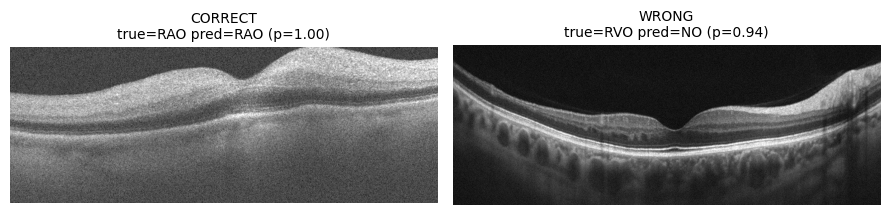

In [25]:
# PICK ONE CORRECT AND ONE WRONG SAMPLE FROM THE (UNTOUCHED) TEST SET

@torch.no_grad()
def evaluate_test_set(paths, labels, batch_size=16):
    all_probs, all_preds = [], []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        imgs = []
        for p in batch_paths:
            with Image.open(p) as im:
                imgs.append(eval_tfms(im.convert("L")))
        x = torch.stack(imgs).to(DEVICE)
        p = F.softmax(final_gnn(x), dim=1).cpu().numpy()
        all_probs.append(p)
        all_preds.append(p.argmax(1))
    return np.concatenate(all_probs), np.concatenate(all_preds)

test_probs, test_preds = evaluate_test_set(test_paths, test_labels)
test_labels_arr = np.array(test_labels)
correct_mask = test_preds == test_labels_arr
wrong_mask = ~correct_mask

print(f"Test accuracy check: {correct_mask.mean():.4f}  "
      f"({correct_mask.sum()} correct / {wrong_mask.sum()} wrong out of {len(test_labels_arr)})")

# Correct sample: pick the highest-confidence correct prediction (clean, illustrative case).
correct_idx = np.where(correct_mask)[0]
correct_conf = test_probs[correct_idx, test_preds[correct_idx]]
correct_choice = correct_idx[np.argmax(correct_conf)]

# Wrong sample: pick a confidently wrong prediction (most informative failure case —
# a low-confidence "near miss" tells you less than a confident mistake).
wrong_idx = np.where(wrong_mask)[0]
wrong_conf = test_probs[wrong_idx, test_preds[wrong_idx]]
wrong_choice = wrong_idx[np.argmax(wrong_conf)]

samples = {
    "correct": {
        "path": test_paths[correct_choice],
        "true_label": classes[test_labels_arr[correct_choice]],
        "pred_label": classes[test_preds[correct_choice]],
        "confidence": float(test_probs[correct_choice, test_preds[correct_choice]]),
    },
    "wrong": {
        "path": test_paths[wrong_choice],
        "true_label": classes[test_labels_arr[wrong_choice]],
        "pred_label": classes[test_preds[wrong_choice]],
        "confidence": float(test_probs[wrong_choice, test_preds[wrong_choice]]),
    },
}
print(json.dumps(samples, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, key in zip(axes, ["correct", "wrong"]):
    with Image.open(samples[key]["path"]) as im:
        ax.imshow(im.convert("L"), cmap="gray")
    s = samples[key]
    ax.set_title(f"{key.upper()}\ntrue={s['true_label']} pred={s['pred_label']} "
                 f"(p={s['confidence']:.2f})", fontsize=10)
    ax.axis("off")
fig.tight_layout()
fig.savefig(XAI_DIR / "selected_samples.png", dpi=200, bbox_inches="tight")
plt.show()


Running LIME on the CORRECT sample...


  0%|          | 0/800 [00:00<?, ?it/s]

/tmp/ipykernel_58/1709188130.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray((g * 255).astype(np.uint8), mode="L").resize((IMAGE_SIZE, IMAGE_SIZE))


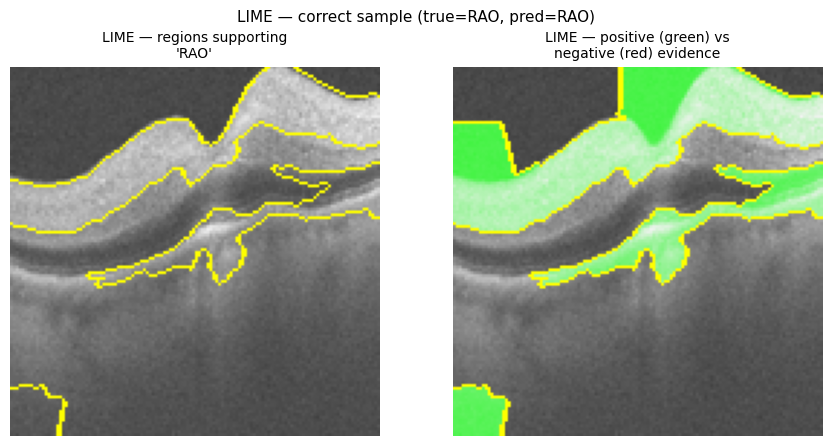

Running LIME on the WRONG sample...


  0%|          | 0/800 [00:00<?, ?it/s]

/tmp/ipykernel_58/1709188130.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray((g * 255).astype(np.uint8), mode="L").resize((IMAGE_SIZE, IMAGE_SIZE))


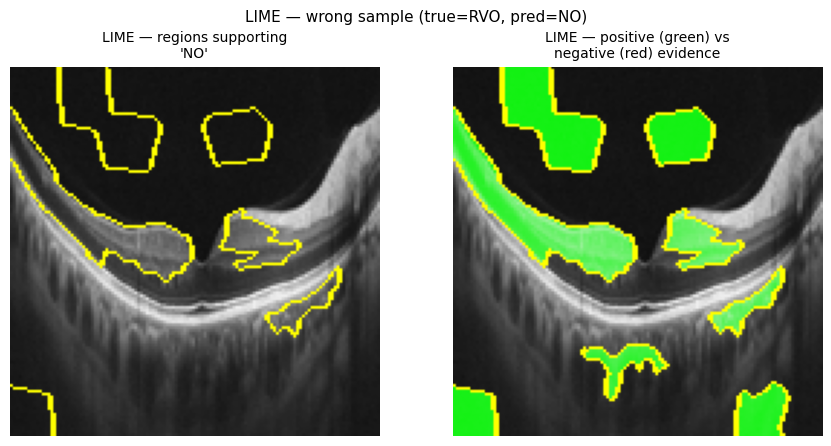

In [26]:
# LIME — local, superpixel-based explanation for both samples

lime_explainer = lime_image.LimeImageExplainer(random_state=SEED)

def run_lime(image_path, top_label_idx, title, save_name):
    rgb = load_rgb_for_explainer(image_path)
    explanation = lime_explainer.explain_instance(
        rgb.astype(np.double),
        classifier_fn=predict_proba,
        top_labels=NUM_CLASSES,
        hide_color=0,
        num_samples=800,
        segmentation_fn=lambda img: slic(img, n_segments=60, compactness=10, sigma=1, start_label=0),
        random_seed=SEED,
    )
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

    temp, mask = explanation.get_image_and_mask(
        top_label_idx, positive_only=True, num_features=8, hide_rest=False
    )
    axes[0].imshow(mark_boundaries(temp / 255.0, mask))
    axes[0].set_title(f"LIME — regions supporting\n'{classes[top_label_idx]}'", fontsize=10)
    axes[0].axis("off")

    temp2, mask2 = explanation.get_image_and_mask(
        top_label_idx, positive_only=False, num_features=10, hide_rest=False
    )
    axes[1].imshow(mark_boundaries(temp2 / 255.0, mask2))
    axes[1].set_title("LIME — positive (green) vs\nnegative (red) evidence", fontsize=10)
    axes[1].axis("off")

    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    fig.savefig(XAI_DIR / save_name, dpi=200, bbox_inches="tight")
    plt.show()
    return explanation


print("Running LIME on the CORRECT sample...")
lime_correct = run_lime(
    samples["correct"]["path"], classes.index(samples["correct"]["pred_label"]),
    f"LIME — correct sample (true={samples['correct']['true_label']}, "
    f"pred={samples['correct']['pred_label']})",
    "lime_correct.png",
)

print("Running LIME on the WRONG sample...")
lime_wrong = run_lime(
    samples["wrong"]["path"], classes.index(samples["wrong"]["pred_label"]),
    f"LIME — wrong sample (true={samples['wrong']['true_label']}, "
    f"pred={samples['wrong']['pred_label']})",
    "lime_wrong.png",
)


Running SHAP on the CORRECT sample (this can take a minute)...


/tmp/ipykernel_58/1709188130.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray((g * 255).astype(np.uint8), mode="L").resize((IMAGE_SIZE, IMAGE_SIZE))


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.85s/it]               
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [63.0..243.0].


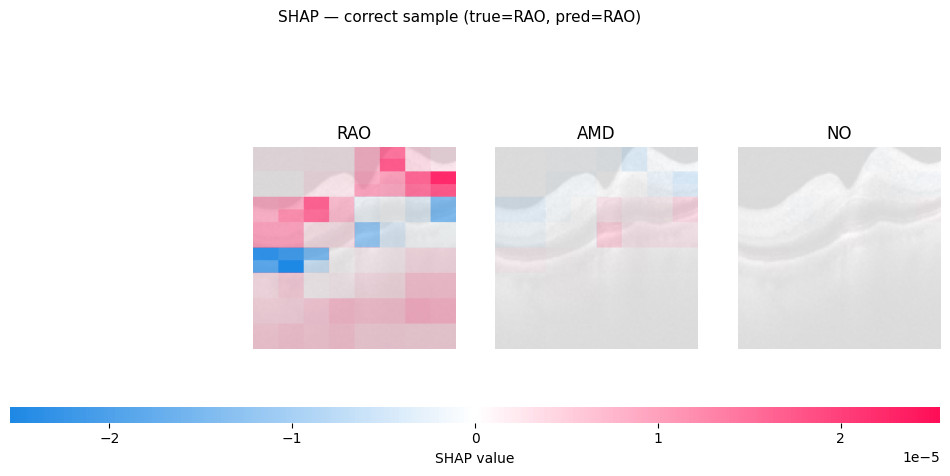

Running SHAP on the WRONG sample (this can take a minute)...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.48s/it]               
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [16.0..241.0].


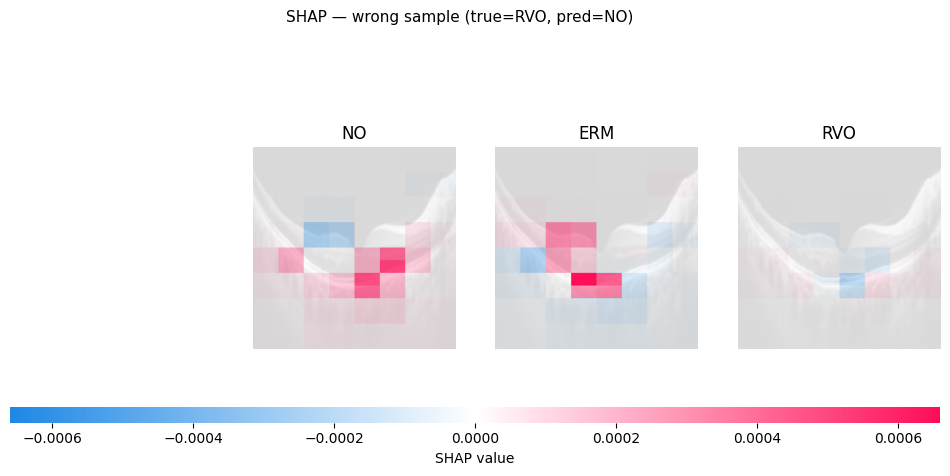

In [27]:
# SHAP — Partition explainer (model-agnostic, works with our custom GNN forward pass)

masker = shap.maskers.Image("blur(32,32)", shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
shap_explainer = shap.Explainer(predict_proba, masker, output_names=classes)


def run_shap(image_path, pred_label_idx, title, save_name, max_evals=500):
    rgb = load_rgb_for_explainer(image_path).astype(np.float32)
    X = np.expand_dims(rgb, axis=0)
    shap_values = shap_explainer(
        X, max_evals=max_evals, batch_size=25,
        outputs=shap.Explanation.argsort.flip[:3]  # explain top-3 predicted classes
    )
    shap.image_plot(shap_values, show=False)
    fig = plt.gcf()
    fig.suptitle(title, fontsize=11, y=1.02)
    fig.savefig(XAI_DIR / save_name, dpi=200, bbox_inches="tight")
    plt.show()
    return shap_values


print("Running SHAP on the CORRECT sample (this can take a minute)...")
shap_correct = run_shap(
    samples["correct"]["path"], classes.index(samples["correct"]["pred_label"]),
    f"SHAP — correct sample (true={samples['correct']['true_label']}, "
    f"pred={samples['correct']['pred_label']})",
    "shap_correct.png",
)

print("Running SHAP on the WRONG sample (this can take a minute)...")
shap_wrong = run_shap(
    samples["wrong"]["path"], classes.index(samples["wrong"]["pred_label"]),
    f"SHAP — wrong sample (true={samples['wrong']['true_label']}, "
    f"pred={samples['wrong']['pred_label']})",
    "shap_wrong.png",
)


In [28]:
# SAVE AN EXPLAINABILITY MANIFEST FOR THE REPORT

xai_manifest = {
    "final_model_config": best_name,
    "correct_sample": samples["correct"],
    "wrong_sample": samples["wrong"],
    "methods": ["LIME (superpixel/SLIC segmentation, 800 perturbation samples)",
                "SHAP (Partition explainer, blur(32,32) masker, top-3 output classes)"],
    "artifacts": [
        "selected_samples.png", "lime_correct.png", "lime_wrong.png",
        "shap_correct.png", "shap_wrong.png",
    ],
}
with open(XAI_DIR / "xai_manifest.json", "w") as f:
    json.dump(xai_manifest, f, indent=2, default=str)
print(json.dumps(xai_manifest, indent=2, default=str))


{
  "final_model_config": "A3_global_fusion",
  "correct_sample": {
    "path": "/kaggle/input/datasets/orvile/octdl-optical-coherence-tomography-dataset/OCTDL/OCTDL/RAO/rao_4888698_1.jpg",
    "true_label": "RAO",
    "pred_label": "RAO",
    "confidence": 0.9995917677879333
  },
  "wrong_sample": {
    "path": "/kaggle/input/datasets/orvile/octdl-optical-coherence-tomography-dataset/OCTDL/OCTDL/RVO/rvo_6113464_2.jpg",
    "true_label": "RVO",
    "pred_label": "NO",
    "confidence": 0.9377358555793762
  },
  "methods": [
    "LIME (superpixel/SLIC segmentation, 800 perturbation samples)",
    "SHAP (Partition explainer, blur(32,32) masker, top-3 output classes)"
  ],
  "artifacts": [
    "selected_samples.png",
    "lime_correct.png",
    "lime_wrong.png",
    "shap_correct.png",
    "shap_wrong.png"
  ]
}
